# Midas Design Guide — Prestressed Concrete Girder Design

**Companion notebook** for the corresponding chapter of the MIDAS training
manual *Design Guide for midas Civil — AASHTO LRFD*. The guide itself is
proprietary and is **not reproduced here** — this notebook contains only
original code and AASHTO LRFD / MBE article citations.

**How this notebook is used.** Work through the design process with this
notebook alongside: each step carries its AASHTO background in original
words, a live Python environment for exploratory checks and quick
validation, a direct interface to Midas Civil through its API, and
customization to ODOT's design process (PSID / PSBD standard products,
ODOT materials and vehicles).
Everything the guide has you do by hand in the Midas UI — coordinate entry,
side math — is demonstrated here as runnable code a designer can follow,
rerun, and modify. Where a number must come from the Midas model itself
(analysis forces, tendon losses per stage, design result tables), there is a
`TODO(midas-api)` marker — those cells get finished against the live Civil
NX JSON API when it is back online. Hand-entered values (from a standard
drawing or a hand calc) are compared via the `check()` harness below.

**Scope of this chapter:**

1. Flexural resistance factor φ (LRFD 5.5.4.2) — the guide's opening calc
2. Parametric section input — strands and rebar by rule, not coordinates
3. Preview and Midas export of the section (API)
4. Neutral axis & strain compatibility (LRFD 5.6.3.2.5) — c, εt, φ, Mn,
   component forces Ts / Cs / Tps, and the composite-topping variant
5. Section properties — gross, transformed, and composite
6. Live load distribution factors (LRFD 4.6.2.2)
7. Dead / live load force effects (from the Midas model — API)
8. Prestress losses — elastic shortening + refined long-term (LRFD 5.9.3)
9. Stress checks at transfer and at service (LRFD 5.9.2.3)
10. Flexural strength, Strength I (LRFD 5.6.3)
11. Minimum reinforcement (LRFD 5.6.3.3)
12. Shear design — sectional MCFT (LRFD 5.7.3)
13. Interface shear and anchorage-zone checks
14. Cross-check against Midas PSC design result tables (API)
15. Capstone: six-beam bridge, HL-93/HS20, deflections, severed-tendon what-ifs


**What the `check()`s compare.** Unless a cell says otherwise, a `check()`
validates one Python derivation against another — the cell's hand calc vs
civilpy's implementation — or against a published constant (an AASHTO
limit, an ODOT sheet value). That proves the walkthrough and the library
agree on the article's math; it is *not* a software cross-check. Labels
mentioning Midas mean one of two things: a **Midas convention computed
here** (e.g. $f_r = 0.37\sqrt{f'_c}$, $\phi = 1.0$ interface shear —
conventions the guide documents, evaluated in Python for comparison), or a
**Midas model value** pulled from Civil NX over the API — live when
connected, otherwise the recorded values noted in the cell. Midas's
design-module result tables are not API-reachable, so civilpy-vs-Midas
*design-check* comparisons remain manual side-by-sides.

In [2]:
import math
import pandas as pd

# civilpy is installed editable into this env (pip install -e .)
from civilpy.structural.midas import MidasCivil, parse_result_table, envelope
from civilpy.structural.aashto.lrfd import (
    concrete, prestressed, steel, composite, distribution, lrfr, creep_shrinkage,
)

# --- Midas Civil NX connection -------------------------------------------------
# The API is not running on this machine right now. Everything below that needs
# the live model is guarded by MIDAS_ONLINE and marked TODO(midas-api).
try:
    midas = MidasCivil()
    MIDAS_ONLINE = midas.ping()
except Exception:
    midas, MIDAS_ONLINE = None, False
print("Midas Civil NX online:", MIDAS_ONLINE)

Midas Civil NX online: True


In [3]:
# --- Validation harness --------------------------------------------------------
# Every comparison in this notebook goes through check() so the end-of-notebook
# summary shows guide value vs civilpy value side by side.
RESULTS = []

def check(label, guide_value, civilpy_value, tol=0.01, unit=""):
    """Compare a guide-reported value against the civilpy-computed one.

    tol is relative (1% default) — the guide rounds intermediate values, so
    small drift is expected; flag anything beyond tol for investigation.
    """
    if guide_value is None or civilpy_value is None:
        status = "PENDING"
        diff = None
    else:
        diff = abs(civilpy_value - guide_value) / (abs(guide_value) or 1.0)
        status = "OK" if diff <= tol else "MISMATCH"
    RESULTS.append({"check": label, "guide": guide_value, "civilpy": civilpy_value,
                    "rel diff": diff, "unit": unit, "status": status})
    print(f"[{status}] {label}: guide={guide_value} civilpy={civilpy_value} {unit}")
    return status == "OK"

def summary():
    df = pd.DataFrame(RESULTS)
    if len(df):
        n_ok = (df.status == "OK").sum()
        print(f"{n_ok}/{len(df)} checks OK, "
              f"{(df.status == 'MISMATCH').sum()} mismatches, "
              f"{(df.status == 'PENDING').sum()} pending")
    return df

## 1. Flexural resistance factor φ — LRFD 5.5.4.2

The guide opens by having you compute the resistance factor by hand from the
net tensile strain before entering it into Midas:

$$0.75 \;\le\; \phi = 0.75 + \frac{0.25\,(\varepsilon_t -
\varepsilon_{cl})}{(\varepsilon_{tl} - \varepsilon_{cl})} \;\le\; 1.0$$

with $\varepsilon_{cl} = 0.002$ (compression-controlled limit) and
$\varepsilon_{tl} = 0.005$ (tension-controlled limit) for Grade ≤ 75
reinforcement / prestressing strand. In civilpy this is
`prestressed.phi_flexure_ps`. The cell below validates the anchor points and
plots the transition.

[OK] phi at eps_t = 0.002 (compression-controlled): guide=0.75 civilpy=0.75 
[OK] phi at eps_t = 0.005 (tension-controlled): guide=1.0 civilpy=1.0 
[OK] phi at eps_t = 0.0035 (transition midpoint): guide=0.875 civilpy=0.875 
[OK] phi floor below eps_cl: guide=0.75 civilpy=0.75 
[OK] phi cap above eps_tl: guide=1.0 civilpy=1.0 


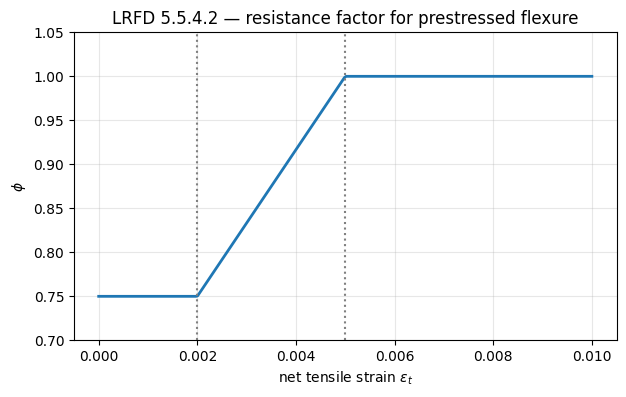

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# anchor-point validation of the 5.5.4.2 equation
check("phi at eps_t = 0.002 (compression-controlled)", 0.75,
      prestressed.phi_flexure_ps(0.002))
check("phi at eps_t = 0.005 (tension-controlled)", 1.00,
      prestressed.phi_flexure_ps(0.005))
check("phi at eps_t = 0.0035 (transition midpoint)", 0.875,
      prestressed.phi_flexure_ps(0.0035))
check("phi floor below eps_cl", 0.75, prestressed.phi_flexure_ps(0.0001))
check("phi cap above eps_tl", 1.00, prestressed.phi_flexure_ps(0.02))

eps = np.linspace(0.0, 0.010, 300)
phi = [prestressed.phi_flexure_ps(e) for e in eps]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps, phi, lw=2)
ax.axvline(0.002, ls=":", color="0.5"); ax.axvline(0.005, ls=":", color="0.5")
ax.set_xlabel(r"net tensile strain $\varepsilon_t$")
ax.set_ylabel(r"$\phi$")
ax.set_title("LRFD 5.5.4.2 — resistance factor for prestressed flexure")
ax.set_ylim(0.7, 1.05); ax.grid(alpha=0.3)
plt.show()

# TODO(guide): when we compute phi*Mn in Sections 4 and 10, eps_t comes from
# strain compatibility at nominal — confirm the guide uses the same
# eps_cl/eps_tl pair (partially prestressed / higher-grade bars differ).

## 2. Parametric section input — replacing the Midas wizards

Midas's PSC wizard wants the rebar and tendon positions as coordinate tables
typed in by hand. `civilpy.structural.psc_section` replaces that with rules
for the shapes ODOT actually uses — PSID-1-13 I-beams and PSBD-1-25 48-in box
beams:

- **strands by count** — fill the standard's permissible grid in its fill order
- **strands by rows** — explicit `{height: count}` for non-standard patterns
- **strands from the ODOT standard design** — the tabulated PSBDD pattern
- **rebar by row / by perimeter** — cage steel from cover + spacing rules

Every layout is checked against the actual solid geometry (a strand can't
land in a box void) and previewed to scale before anything goes to Midas.

In [ ]:
from civilpy.structural.psc_section import (
    i_beam_shape, box_beam_shape, box_standard_bars, strands_by_count,
    strands_by_rows, strands_from_odot_design, shipping_strands,
    rebar_row, perimeter_bars, plot_psc_section,
    midas_strand_coordinates, midas_rebar_coordinates,
)

# Way 1 — "give me 36 strands" on a WF72-49: the PSID permissible grid
# ('+' marks) fills bottom row up, outermost first; 'x' marks are the
# web locations that must be draped if used; '^' marks are the top-flange
# shipping strand locations (Way 2 below).
wf = i_beam_shape("WF72-49")
wf_strands = strands_by_count(wf, 36)
plot_psc_section(wf, wf_strands, title="WF72-49 — 36 strands by count")
plt.show()
check("WF72-49 permissible strand locations", 62, len(wf.strand_grid))

# The outline follows the PSID-1-13 sheet 2-3 dimension stack — a 5 in
# vertical tip edge on the top flange, then 3 in drops over 1'-5 1/2 in
# and 3 in runs into the 8 in web.  Drawn that way the polygon closes on
# the published gross area (chamfers are all that's left out):
_o = wf.outline
_area = 0.5 * abs(sum(_o[i][0] * _o[(i + 1) % len(_o)][1]
                      - _o[(i + 1) % len(_o)][0] * _o[i][1]
                      for i in range(len(_o))))
check("drawn WF72-49 outline area vs published (in^2)", wf.area_in2,
      round(_area, 1), tol=1.0)


In [ ]:
# Way 2 — explicit rows for a non-standard pattern (here: a heavier
# bottom bundle), then the standard's actual shipping strands on top.
# PSID-1-13 puts six shipping strand locations in the top flange at
# y = ±6, ±8, ±10 in with centers 2¾ in below the top surface (the same
# "2¾ (TYP.)" line the D31 flange-tip wires sit on).  They stabilize
# the beam for handling and are tensioned per the PSID general notes —
# not design prestress, so keep them out of the flexural checks unless
# the design counts them.
custom = strands_by_rows(wf, {2.0: 15, 4.0: 13, 6.0: 8}) + shipping_strands(wf)
plot_psc_section(wf, custom,
                 title="WF72-49 — pattern by rows + shipping strands")
plt.show()
check("shipping strands sit 2.75 in below the top surface", wf.depth_in - 2.75,
      max(z for _, z in custom.points))
check("shipping strand rows", [-10.0, -8.0, -6.0, 6.0, 8.0, 10.0],
      sorted(y for y, z in custom.points if z > 60.0))


In [ ]:
# Way 3 — the ODOT standard design straight off PSBDD-1-25: box
# designation + span. Row counts come from the sheet; the strand-group
# centroid must reconcile with the sheet's tabulated eccentricity.
box = box_beam_shape("CB27-48")
box_strands = strands_from_odot_design("CB27-48", 70)
print(box_strands.source)
from civilpy.structural.odot.box_beam_design import box_beam_design
d = box_beam_design("CB27-48", 70)
check("CB27-48 @ 70 ft strand count", d.n_strands, box_strands.n)
check("strand eccentricity vs sheet e_beam (in)", d.e_beam,
      box_strands.eccentricity_in, tol=0.01)

# Longitudinal rebar: PSBD-1-25 sheet 2 note 2 — the minimum is just
# (4) #5 across the top flange and (2) #5 in the bottom.  The bottom
# pair sits *in* the 2 in strand row, 8 in from each outside face
# (y = ±16), so those two lattice points belong to the bars and are not
# permissible strand locations — the grid excludes them.  Everything
# else in the cage (the A..T #4 bars) is transverse steel and doesn't
# appear in a cross-section layout.  rebar_row()/perimeter_bars() stay
# available for non-standard cages.
bars = box_standard_bars(box)
plot_psc_section(box, box_strands, bars,
                 title="CB27-48 — PSBDD standard pattern + note-2 bars")
plt.show()
check("minimum longitudinal steel (4 top + 2 bottom #5)", 6, bars.n)
check("bottom bars displace the y=±16 strand locations", False,
      (16.0, 2.0) in box.strand_grid)


## 3. Export to Midas — the verified push workflow

The layouts convert to the exact JSON payloads Civil NX takes — this is the
part that kills the by-hand wizard workflow. Everything below was verified
against a live Civil NX session (2026-07-27) by building this very beam
through the API:

- `midas_section_payload(box)` → a **PSC-VALUE** section carrying the
  outline and void polygons verbatim (`PUT /db/SECT`). The value section
  reproduced the parametric geometry exactly — Midas's computed area
  (738.0 in²) and inertia (67,335 vs our polygon's 67,326 in⁴) match to
  0.01%.
- `midas_tendon_payloads(strands, ...)` → the three tendon tables:
  **TDNT** (property — strand area lives here; note `D_AREA` must be
  positive even for pretension), **TDNA** (straight profiles — coordinates
  are about the *element axis = section centroid*, exactly the
  `origin="centroid"` rows), **TDPL** (jacking stress).
- Pretension transfer behaves correctly: 0.75fpu jacking came back as
  −980 kips at midspan (≈9.4% immediate loss — elastic shortening handled
  automatically on the transformed section).

Quirks worth knowing: `/doc/new` and `/doc/ANAL` need `{"Argument": {}}`;
support constraints are 7-character strings; editing load combinations
invalidates results (re-analyze); the app serializes API calls, so a
running solve blocks everything else.

In [9]:
from civilpy.structural.psc_section import (
    midas_section_payload, midas_tendon_payloads,
)

sect_payload = midas_section_payload(box)
tendon_payloads = midas_tendon_payloads(
    box_strands, elems=list(range(1, 15)), length_in=70.0 * 12.0,
    matl_id=2, jack_stress_ksi=0.75 * 270.0)
print("SECT: PSC-VALUE,", len(sect_payload["SECT_BEFORE"]["SECT_I"]
      ["OUTER_POLYGON"][0]["VERTEX"]), "outline vertices")
print("TDNT/TDNA/TDPL:", len(tendon_payloads["TDNA"]), "tendons")

# Flip to True to push into the live Civil NX session (overwrites the
# section/tendons at these IDs — deliberate opt-in, not a side effect of
# running the notebook):
PUSH_TO_MIDAS = True
if MIDAS_ONLINE and PUSH_TO_MIDAS:
    midas.put_db("SECT", {"1": sect_payload})
    for table in ("TDNT", "TDNA", "TDPL"):
        midas.request("PUT", f"/db/{table}",
                      {"Assign": tendon_payloads[table]})
    print("pushed section + tendons")

SECT: PSC-VALUE, 4 outline vertices
TDNT/TDNA/TDPL: 32 tendons


MidasApiError: PUT /db/SECT returned HTTP 400: {'error': {'message': '[Error] Section Data can be added/modified/deleted in Base Stage only.'}}

In [10]:
if MIDAS_ONLINE:
    # Verified vs live Civil NX 2026-07-27: /post/TABLE selects by
    # TABLE_TYPE ("BEAMSTRESSPSC"); TABLE_NAME is just a label.
    try:
        resp = midas.result_table("PSC section stress check points",
                                  table_type="BEAMSTRESSPSC")
        display(pd.DataFrame(parse_result_table(resp)).head())
    except Exception as err:
        # a fresh/unanalyzed session (or a DB edit, or a pre-mode view
        # switch) clears results — analyze and rerun this cell
        print("no results in the session:", str(err)[-80:])
else:
    print("Midas offline — skipping PSC section stress check points (BEAMSTRESSPSC)")

no results in the session: ress check points] Cannot generate table data as there is no analysis result.'}}


## 4. Neutral axis & strain compatibility — LRFD 5.6.3.2.5

The guide's next hand calc, driven entirely by the coordinate data we just
built:

1. **Extreme fibers** from the section coordinates — bottom fiber in tension
   for sagging, top fiber for hogging.
2. **Strain field** pinned at $\varepsilon_{cu} = 0.003$ on the compression
   fiber; the tendon closest to the extreme tension fiber sets
   $\varepsilon_t$.
3. **Neutral axis**: start at $H/2$ and iterate $c$ until
   $C_c + C_s - (T_s + T_{ps}) = 0$ — concrete block on the *actual* solid
   geometry (flanges, tapers, voids), mild steel elastic–perfectly-plastic,
   tendons on the Grade 270 power formula with the effective-prestress
   strain added.

`flexural_strain_compatibility` does the whole loop and reports $c$,
$\varepsilon_t$, $\phi$ (5.5.4.2, Section 1's curve), and $M_n$.

In [ ]:
from dataclasses import asdict
from civilpy.structural.psc_section import (
    flexural_strain_compatibility, extreme_fibers,
)

print("extreme fibers (z_bottom, z_top):", extreme_fibers(box))

# TODO(guide): f_pe below is a placeholder effective prestress until the
# Section 8 losses are computed; f_c from the design's specified strength.
res = flexural_strain_compatibility(box, box_strands, f_c=7.0, f_pe=160.0)
check("equilibrium residual (kips)", 0.0, round(res.residual_kips, 6), tol=1e-3)
check("phi consistent with the 5.5.4.2 curve",
      prestressed.phi_flexure_ps(res.eps_t), res.phi)
print(f"c = {res.c_in:.2f} in, a = {res.a_in:.2f} in, "
      f"eps_t = {res.eps_t:.5f} at d_t = {res.d_t_in:.1f} in -> "
      f"phi = {res.phi}, Mn = {res.m_n_kipft:.0f} kip-ft")

# The converged state, drawn.  Left: the section with the compression
# zone (the 0.85 f'c equivalent block over a = beta_1*c) shaded above
# the neutral axis and the tension-side tendons below it.  Right: the
# linear strain diagram — eps_cu = 0.003 at the top fiber, zero at the
# NA — with each tendon row's compatibility strain marked and its
# stress/force annotated (the FiberForce table the hand calc tabulates).
z_bot, z_top = extreme_fibers(box)
beta1 = res.a_in / res.c_in
fig, (axs, axe) = plt.subplots(
    1, 2, figsize=(11.5, 5.4), sharey=True, width_ratios=[1.4, 1.0])
plot_psc_section(box, box_strands, ax=axs, annotate=False)
axs.axhspan(z_top - res.a_in, z_top, color="crimson", alpha=0.20)
axs.axhline(z_top - res.c_in, color="crimson", lw=1.2)
axs.annotate(f"$0.85f'_c$ block\n$a=\\beta_1 c$ = {beta1:.2f}"
             f"$\\times${res.c_in:.2f} = {res.a_in:.2f} in",
             (0.0, z_top - res.a_in / 2.0), ha="center", va="center",
             fontsize=9, color="darkred")
axs.annotate(f"neutral axis, c = {res.c_in:.2f} in",
             (-22.0, z_top - res.c_in), xytext=(-22.0, z_top - res.c_in - 4),
             fontsize=9, color="crimson",
             arrowprops=dict(arrowstyle="->", color="crimson"))
axs.annotate(f"tension side: {box_strands.n} tendons\n"
             f"$T_{{ps}}$ = {res.t_ps_kips:.0f} kip vs "
             f"$C_c$ = {res.c_c_kips:.0f} kip",
             (0.0, 3.0), ha="center", fontsize=9, color="midnightblue")
axs.set_title("section: compression block vs tension steel")

eps_top = -0.003                                  # compression negative
slope = -eps_top / res.c_in                       # strain per inch below top
axe.plot([eps_top + slope * (z_top - z) for z in (z_bot, z_top)],
         [z_bot, z_top], color="black", lw=1.2)
axe.axvline(0.0, color="0.6", lw=0.8)
axe.axhline(z_top - res.c_in, color="crimson", lw=1.0, ls=":")
axe.annotate(r"$\varepsilon_{cu}$ = 0.003", (eps_top, z_top),
             textcoords="offset points", xytext=(6, -12), fontsize=9)
# one point per tendon row, ON the compatibility line; the FiberForce
# eps is the TOTAL tendon strain (section strain + eps_pe + eps_ce —
# the Section 4 stack), which is what the power formula turns into f_ps
rows = {}
for t in res.tendon_forces:
    rows.setdefault(round(t.d_in, 3), []).append(t)
for d, ts in sorted(rows.items()):
    z = z_top - d
    e_line = eps_top + slope * d
    axe.plot(e_line, z, "o", color="steelblue", ms=6)
    axe.annotate(
        f"row z={z:g}: $\\varepsilon_c$={e_line:.4f} "
        f"$\\rightarrow \\varepsilon_{{ps}}$={ts[0].eps:.4f}\n"
        f"f={ts[0].f_ksi:.0f} ksi, {len(ts)} strands, "
        f"{sum(t.force_kips for t in ts):.0f} k",
        (e_line, z), textcoords="offset points", xytext=(-8, 8),
        ha="right", fontsize=8)
axe.set_xlabel("section (compatibility) strain (tension +)")
axe.set_title(r"strain diagram ($E_p$=28,500, $E_s$=29,000 ksi)")
fig.tight_layout()
plt.show()
# The dots sit on the linear section-strain diagram; the arrow in each
# label adds the effective-prestress strain f_pe/E_p and decompression
# strain to get the total tendon strain eps_ps — exactly the Section 4
# hand-calc stack — before the power formula turns it into f_ps.


In [12]:
# hogging flips the compression fiber to the bottom — with all the
# strands now near the compression face the section is
# compression-controlled and phi drops to 0.75
hog = flexural_strain_compatibility(box, box_strands, f_c=7.0, f_pe=160.0,
                                    bending="hogging")
cols = ["bending", "c_in", "a_in", "d_t_in", "eps_t", "phi",
        "f_ps_extreme_ksi", "m_n_kipft"]
pd.DataFrame([asdict(res), asdict(hog)])[cols].round(4)

# TODO(midas-api): pull Midas's own neutral-axis depth / fps from the PSC
# design result detail and check() them against res above.

,bending,c_in,a_in,d_t_in,eps_t,phi,f_ps_extreme_ksi,m_n_kipft
0,sagging,6.8287,4.7801,25.0,0.0080,1.00,256.2923,2458.8633
1,hogging,3.8431,2.6902,4.0,0.0001,0.75,162.6575,114.3683


### Component forces — the guide's Eqs. 1.3–1.6

The guide tabulates the intermediates per component: strain from
compatibility ($\varepsilon_s = \tfrac{d_t - c}{c}\varepsilon_{cu}$,
$\varepsilon_s' = \tfrac{c - d_c}{c}\varepsilon_{cu}$, their Eq. 1.4),
stress elastic up to yield ($f_s = \varepsilon_s E_s \le f_y$, Eq. 1.5),
then $T_s = A_s f_s$, $C_s = A_s' f_s'$ (Eq. 1.3) and
$T_{ps} = \Sigma A_p f_{ps}$ (Eq. 1.6). `FlexuralResult` carries the same
per-bar / per-strand rows. Note the guide's $C_s$ is the *bare*
$A_s' f_s'$ — `displaced_concrete_credit=False` reproduces that
convention.

In [ ]:
det = flexural_strain_compatibility(box, box_strands, f_c=7.0, f_pe=160.0,
                                    displaced_concrete_credit=False)
check("T_ps equals the per-strand sum (kips)",
      round(sum(t.force_kips for t in det.tendon_forces), 6),
      round(det.t_ps_kips, 6), tol=1e-6)
print(f"T_s = {det.t_s_tension_kips:.1f} kip, C_s = {det.c_s_kips:.1f} kip, "
      f"T_ps = {det.t_ps_kips:.1f} kip vs C_c = {det.c_c_kips:.1f} kip")
# Status (re-verified against the live API, 2026-07-27): Midas's PSC
# *design-module* result tables are not exposed over the JSON API —
# every design TABLE_TYPE probe returns HTTP 400; only analysis result
# tables are reachable.  So this table is civilpy's strain-compatibility
# detail, not a Midas number, and the comparison against Midas's design
# detail report (same component forces, plus whether Midas deducts
# displaced concrete from block-side steel) has to be a manual
# side-by-side: Design > PSC Design > Design Result Detail on the same
# section.
pd.DataFrame(det.table()).round(4)

In [15]:
# The same calc by hand, for the governing strand — plain Python you can
# copy and modify for exploratory checks. This is exactly what civilpy
# (and Midas) do inside for every strand.
c, eps_cu, E_p, f_pe, A_p = det.c_in, 0.003, 28500.0, 160.0, 0.167
d_p = max(t.d_in for t in det.tendon_forces)      # strand nearest the
                                                  # extreme tension fiber
eps_ps = f_pe / E_p + (d_p - c) / c * eps_cu      # Eq 1.4 + prestress
# Grade 270 low-relaxation power formula (PCI), elastic at small strain:
f_ps = min(eps_ps * (887 + 27613 / (1 + (112.4 * eps_ps)**7.36)**(1/7.36)),
           270.0)                                  # Eq 1.5 (strand form)
force = A_p * f_ps                                 # one term of Eq 1.6
gov = max(det.tendon_forces, key=lambda t: t.d_in)
check("hand calc: strand strain", round(gov.eps, 6), round(eps_ps, 6))
check("hand calc: strand stress (ksi)", round(gov.f_ksi, 3), round(f_ps, 3))
check("hand calc: strand force (kips)", round(gov.force_kips, 3),
      round(force, 3))

[OK] hand calc: strand strain: guide=0.013597 civilpy=0.013597 
[OK] hand calc: strand stress (ksi): guide=256.292 civilpy=256.292 
[OK] hand calc: strand force (kips): guide=42.801 civilpy=42.801 


True

In [16]:
# The composite-PSC menu: same solve with the CIP structural topping
# (PSBD-1-25 general notes: 5 in structural topping, f'c = 4.5 ksi CIP).
# beta1 follows the topping concrete at the compression fiber and the
# block is integrated per material.
from civilpy.structural.psc_section import composite_topping

comp = flexural_strain_compatibility(
    box, box_strands, f_c=7.0, f_pe=160.0,
    topping=composite_topping(box), topping_f_c=4.5)
reach = "into the girder flange" if comp.a_in > 5.0 else "only the topping"
print(f"composite: c = {comp.c_in:.2f} in, a = {comp.a_in:.2f} in "
      f"(block reaches {reach}), eps_t = {comp.eps_t:.5f}, "
      f"phi = {comp.phi}, Mn = {comp.m_n_kipft:.0f} kip-ft "
      f"(vs {res.m_n_kipft:.0f} kip-ft non-composite)")

composite: c = 7.97 in, a = 6.58 in (block reaches into the girder flange), eps_t = 0.00829, phi = 1.0, Mn = 2899 kip-ft (vs 2459 kip-ft non-composite)


### Tendon stress $f_{ps}$ — code method vs strain compatibility

Midas Civil has a **Flexural Strength Option** toggle: *code* or *strain
compatibility*. With *code* selected, $f_{ps}$ comes from the AASHTO closed
forms — 5.6.3.1.1 for bonded tendons, 5.6.3.1.2 for unbonded. With *strain
compatibility*, $f_{ps}$ comes from the strand stress–strain relationship,
exactly as Section 4 computed it.

**Tendon type and bond type.** Midas offers three tendon types; the bond
type follows from the physics of each:

| Tendon type | Bond type | Section properties |
|---|---|---|
| Internal (Pre-Tension) | Bonded *(forced)* | no ducts — strand bears on concrete directly |
| Internal (Post-Tension) | Bonded | duct area restored after grouting |
| Internal (Post-Tension) | Unbonded | duct area stays deducted |
| External | Unbonded *(forced)* | tendon outside the concrete entirely |

**Which to select, and why** (the guide never actually says): *bonded* means
the tendon strain tracks the concrete strain at every cross-section, which
is what lets a bonded tendon reach a stress near $f_{pu}$ at the critical
section. The PSID I-beams and PSBD box
beams are plant-pretensioned products → **Internal (Pre-Tension)**, bonded
by definition — though note ODOT *suggests* rather than mandates the
standard drawings, so pick the tendon type from the actual fabrication
method on the shop drawings, not from the assumption that the standard was
followed. Grouted multistrand post-tensioning (e.g. spliced girders) →
Internal (Post-Tension), Bonded. Greased single-strand systems or ducts
deliberately left ungrouted → Internal (Post-Tension), Unbonded. Tendons
running outside the section (segmental boxes, strengthening retrofits) →
External, always unbonded. An unbonded tendon slips relative to the
concrete, so its strain change averages over the whole free length instead
of peaking at the critical section — its $f_{ps}$ at strength is much lower
(quantified two cells down).

**Method × bond matrix** (the guide's Table 1.2): code + bonded →
5.6.3.1.1; code + unbonded → 5.6.3.1.2; strain compatibility + bonded →
stress–strain relationship; strain compatibility + unbonded → **Midas
silently substitutes the 5.6.3.1.2 code equation**, because strain
compatibility presumes full bond — worth knowing before comparing outputs.

$A_p$ Midas totals automatically from the strand count, same as our layout
(`box_strands.a_ps`); the material inputs are $f_{pu}$ and $f_{py}$
(0.90 $f_{pu}$ for low-relaxation strand).

The code equations, bonded (5.6.3.1.1-1 and -2):

$$f_{ps} = f_{pu}\left(1 - k\,\frac{c}{d_p}\right), \qquad
k = 2\left(1.04 - \frac{f_{py}}{f_{pu}}\right)$$

and unbonded (5.6.3.1.2-1 and -2):

$$f_{ps} = f_{pe} + 900\,\frac{d_p - c}{l_e} \le f_{py}, \qquad
l_e = \frac{2\,l_i}{2 + N_s}$$

In [17]:
# Bonded, code method (5.6.3.1.1) — k first, then f_ps with the
# closed-form neutral axis. civilpy's ps_strand_stress_at_nominal does
# the pair together; k is one line of plain math:
f_pu, f_py = 270.0, 0.90 * 270.0
k = 2 * (1.04 - f_py / f_pu)                       # 5.6.3.1.1-2
check("k for low-relaxation strand", 0.28, round(k, 6))

d_p = box.depth_in - box_strands.centroid_in       # 24.0 in to the group cg
code_fps = prestressed.ps_strand_stress_at_nominal(
    a_ps=box_strands.a_ps, f_pu=f_pu, d_p=d_p, f_c=7.0,
    b=48.0, b_w=12.0, h_f=5.5)                     # two 6 in walls
avg_sc_fps = det.t_ps_kips / box_strands.a_ps      # strain-compat average
print(f"code f_ps = {code_fps.capacity:.1f} ksi vs strain-compatibility "
      f"average {avg_sc_fps:.1f} ksi")
check("code vs strain-compatibility f_ps (ksi)", round(code_fps.capacity, 1),
      round(avg_sc_fps, 1), tol=0.05)  # different methods; ~3% apart here

[OK] k for low-relaxation strand: guide=0.28 civilpy=0.28 
code f_ps = 257.5 ksi vs strain-compatibility average 255.5 ksi
[OK] code vs strain-compatibility f_ps (ksi): guide=257.5 civilpy=255.5 


True

In [18]:
# Unbonded (5.6.3.1.2), inline — what Midas falls back to whenever the
# bond type is unbonded, even with strain compatibility selected. The
# tendon strain averages over the free length l_e, so f_ps barely rises
# above the effective prestress:
f_pe = 160.0
l_i = 70.0 * 12.0        # tendon length between anchorages, in
N_s = 0                  # plastic hinges crossed (simple span: 0)
l_e = 2 * l_i / (2 + N_s)                          # 5.6.3.1.2-2
f_ps_u = f_pe + 15.0                               # AASHTO's suggested start
for _ in range(20):                                # fixed-point iteration
    c_u = box_strands.a_ps * f_ps_u / (0.85 * 7.0 * 0.70 * 48.0)
    f_ps_u = min(f_pe + 900.0 * (d_p - c_u) / l_e, f_py)  # 5.6.3.1.2-1
print(f"unbonded f_ps = {f_ps_u:.1f} ksi at c = {c_u:.2f} in — "
      f"vs {code_fps.capacity:.1f} ksi bonded: the bond type is worth "
      f"{code_fps.capacity - f_ps_u:.0f} ksi of tendon stress at strength")

# the same check as a civilpy call (5.6.3.1.2 lives in the library too):
unb = prestressed.ps_strand_stress_unbonded(
    a_ps=box_strands.a_ps, f_pe=f_pe, d_p=d_p, f_c=7.0, b=48.0,
    l_i=l_i, n_s=N_s, f_py=f_py, b_w=12.0, h_f=5.5)
check("hand iteration vs civilpy 5.6.3.1.2 (ksi)", round(f_ps_u, 2),
      round(unb.capacity, 2))
# TODO(midas-api): flip the Midas toggle both ways on the same model and
# check() its f_ps against code_fps / avg_sc_fps / unb.capacity above.

unbonded f_ps = 180.5 ksi at c = 4.83 in — vs 257.5 ksi bonded: the bond type is worth 77 ksi of tendon stress at strength
[OK] hand iteration vs civilpy 5.6.3.1.2 (ksi): guide=180.54 civilpy=180.54 


True

### The stress–strain model, convergence, and $M_n$ — Eqs. 1.11–1.14

With *strain compatibility* selected, $f_{ps}$ comes straight off the strand
stress–strain model below — linear at $E_p$ = 28,500 ksi, rounding over
between $f_{py}$ and $f_{pu}$ (the PCI power formula for Grade 270
low-relaxation strand).

Midas iterates the neutral axis until compression balances tension,
$C = C_c + C_s$ against $T = T_s + T_{ps}$, declaring convergence at

$$\left|\frac{C}{T} - 1\right| < 0.001$$

(their Eq. 1.11 — a relative force balance; civilpy iterates the same
equilibrium to a much tighter absolute tolerance, so it always satisfies
Midas's criterion).

$M_n$ is then the sum of every force times its moment arm (Eq. 1.12) —
Midas measures arms from the neutral axis:

$$M_n = C_c a_c + C_s a_s' + T_s a_s + \Sigma\, T_{ps} a_{pi}$$

with the sign rule of Eq. 1.13: a tendon in *tension above* the NA under
sagging gets a negative arm and **reduces** $M_n$ (think top shipping
strands). Because the section is in equilibrium, moments taken about the NA,
the compression fiber, or anywhere else agree — demonstrated below. Finally
the factored resistance (Eq. 1.14 = AASHTO 5.6.3.2.1-1):
$M_r = \phi M_n$.

In [ ]:
# the strand stress-strain model (what Midas plots in the guide)
from civilpy.structural.psc_section import strand_stress_270

# Grades: strand_stress_270 is the Devalapura/Tadros power-formula fit
# for Grade 270 LOW-RELAXATION strand only — which is all either ODOT
# standard specifies (PSID-1-13: 0.6 in dia; PSBD-1-25: 0.5 in dia,
# both Grade 270 low-lax).  For anything else (Grade 250,
# stress-relieved) civilpy's AASHTO closed forms take f_pu/f_py
# directly — prestressed.ps_strand_stress_at_nominal (5.6.3.1.1) and
# ps_strand_stress_unbonded (5.6.3.1.2) work for any grade — but a
# strain-compatibility run on non-270 strand needs its own
# stress-strain fit in place of this curve.

eps = np.linspace(0.0, 0.03, 400)
sig = [strand_stress_270(e) for e in eps]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps, sig, lw=2)
ax.plot([0, 0.0095], [0, 0.0095 * 28500], "--", lw=1, color="0.5",
        label=r"elastic, $E_p$ = 28,500 ksi")
ax.axhline(270.0, ls=":", color="0.6"); ax.axhline(243.0, ls=":", color="0.6")
ax.annotate(r"$f_{pu}$ = 270", (0.026, 271), fontsize=9)
ax.annotate(r"$f_{py}$ = 243 = 0.9$f_{pu}$", (0.026, 244), fontsize=9)
ax.set_xlabel("strain"); ax.set_ylabel("stress (ksi)")
ax.set_title("Grade 270 low-relaxation strand — power formula")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.show()
check("elastic slope E_p (ksi)", 28500,
      round(strand_stress_270(1e-4) / 1e-4))

In [21]:
# Midas's convergence criterion (Eq. 1.11) on our converged state
C = det.c_c_kips + det.c_s_kips
T = det.t_s_tension_kips + det.t_ps_kips
print(f"C = {C:.1f} kip, T = {T:.1f} kip, |C/T - 1| = {abs(C / T - 1):.2e}")
check("|C/T - 1| < 0.001 (Midas tolerance)", True, bool(abs(C / T - 1) < 0.001))

# Mn as force x arm about the neutral axis (Eq. 1.12). The stress block
# sits fully inside the 48 in top flange here, so its centroid is a/2:
arm_cc = det.c_in - det.a_in / 2.0
mn_na = (det.c_c_kips * arm_cc
         + sum(f.force_kips * (f.d_in - det.c_in)
               for f in det.bar_forces + det.tendon_forces)) / 12.0
check("Mn about the NA = solver Mn (kip-ft)",
      round(det.m_n_kipft, 1), round(mn_na, 1))

# Eq. 1.13's sign rule: tension tendons ABOVE the NA (d < c) reduce Mn
above = [f for f in det.tendon_forces
         if f.force_kips > 0 and f.d_in < det.c_in]
print(f"{len(above)} tendons in tension above the NA "
      "(bottom-strand box: none — draped/top strands would land here)")

# Factored flexural resistance (Eq. 1.14 = AASHTO 5.6.3.2.1-1)
print(f"Mr = phi * Mn = {det.phi:.2f} x {det.m_n_kipft:.0f} "
      f"= {det.phi * det.m_n_kipft:.0f} kip-ft")

C = 1365.2 kip, T = 1365.2 kip, |C/T - 1| = 3.78e-10
[OK] |C/T - 1| < 0.001 (Midas tolerance): guide=True civilpy=True 
[OK] Mn about the NA = solver Mn (kip-ft): guide=2458.9 civilpy=2458.9 
0 tendons in tension above the NA (bottom-strand box: none — draped/top strands would land here)
Mr = phi * Mn = 1.00 x 2459 = 2459 kip-ft


## 5. Section properties

Gross girder, transformed (with strands), and short/long-term composite
sections. The guide tabulates these early in the chapter — validate before
anything downstream depends on them.

Effective flange width per LRFD 4.6.2.6 via
`distribution.effective_flange_width`.

In [ ]:
# TODO(guide): compute gross / transformed / composite properties and
# check() each against the guide's section-property table.
#   - civilpy.structural.section_properties for built-up shapes
#   - distribution.effective_flange_width(...) for the composite deck width
#   - concrete.modulus_of_rupture, modular ratios from Ec of deck vs girder
pass

## 6. Live load distribution factors — LRFD 4.6.2.2

Interior and exterior girder, moment and shear, one lane and multi-lane, plus
skew corrections if the example is skewed. The guide reports these to 3
decimals — good early validation targets.

In [ ]:
# TODO(guide): fill inputs, then e.g.
# kg = distribution.longitudinal_stiffness_kg(...)
# dfm_i = distribution.moment_df_interior(S=..., L=..., ts=..., kg=..., n_lanes=...)
# check("DF moment interior (multi-lane)", <guide>, dfm_i.governing)
# dfv_i = distribution.shear_df_interior(...)
# ...exterior via lever rule: distribution.lever_rule_exterior(...)
pass

## 7. Force effects from the Midas model

Unfactored DC, DW, and HL-93 moments/shears at the check sections (transfer,
harp point, midspan, critical shear section). These come out of the Civil NX
model, so this whole section is API-gated.

In [ ]:
if MIDAS_ONLINE:
    # Verified vs live Civil NX 2026-07-27: /post/TABLE selects by
    # TABLE_TYPE ("BEAMFORCE"); TABLE_NAME is just a label.
    try:
        resp = midas.result_table("BeamForce",
                                  table_type="BEAMFORCE")
        display(pd.DataFrame(parse_result_table(resp)).head())
    except Exception as err:
        # a fresh/unanalyzed session (or a DB edit, or a pre-mode view
        # switch) clears results — analyze and rerun this cell
        print("no results in the session:", str(err)[-80:])
else:
    print("Midas offline — skipping BeamForce (BEAMFORCE)")

## 8. Prestress losses — LRFD 5.9.3

Elastic shortening at transfer, then the refined long-term estimate: shrinkage
and creep of girder concrete (transfer→deck, deck→final), relaxation, and the
deck-placement stage terms including deck-shrinkage gain. Midas computes these
per construction stage — the guide tabulates each component.

In [ ]:
# TODO(guide): validate each loss component individually:
#   prestressed.ps_elastic_shortening_loss(...)
#   prestressed.ps_refined_loss_shrinkage_girder(...)
#   prestressed.ps_refined_loss_creep_girder(...)
#   prestressed.ps_refined_loss_relaxation(...)
#   prestressed.ps_refined_loss_shrinkage_deck_stage(...)
#   prestressed.ps_refined_loss_creep_deck_stage(...)
#   prestressed.ps_deck_shrinkage_gain(...)
# creep/shrinkage material params: creep_shrinkage.creep_coefficient(...),
#   creep_shrinkage.shrinkage_strain(...)
# TODO(midas-api): pull the per-stage tendon loss table from Civil NX and
# reconcile with both the guide table and the civilpy refined estimate.
pass

## 9. Concrete stress checks — construction stages and service

**Construction stages (LRFD 5.9.2.3.1).** Midas compares the stresses of
every construction stage and step against the allowables *of that moment in
time*:

- **Compression:** $\sigma_{ca} = 0.65 f'_{ci}$ (5.9.2.3.1a; 0.60 before
  the 2016 interims — civilpy's `design_year` handles historical designs).
- **Tension** (5.9.2.3.1b, non-segmental rows): in areas without bonded
  reinforcement, $0.0948\sqrt{f'_{ci}} \le 0.2$ ksi; with bonded
  reinforcement sized to carry the full tension force,
  $0.24\sqrt{f'_{ci}}$. Which zone is *precompressed* follows the 5.2
  definitions.
- **Bonded-reinforcement sizing:** Midas builds the triangular tension
  block on the uncracked section and requires the steel to carry its
  resultant at $f_s \le \min(0.5 f_y, 30\ \text{ksi})$ — demoed below.
- **$f'_{ci}$ at load time:** computed per stage from the user's stage
  durations + step days + element activation age on the time-dependent
  strength curve, so the allowables move as the concrete matures.

Service checks after losses (5.9.2.3.2: 0.45/0.60 $f'_c$ compression
cases, Service III tension) join once the Midas force effects land.

In [ ]:
f_ci = 4.5    # release strength inside the PSBD 4.0-5.0 ksi range
comp = prestressed.ps_transfer_compression_check(f_ci=f_ci)
ten0 = prestressed.ps_transfer_tension_check(f_ci=f_ci)
ten1 = prestressed.ps_transfer_tension_check(f_ci=f_ci,
                                             bonded_reinforcement=True)
check("compression allowable 0.65*f'ci (ksi)", round(0.65 * f_ci, 3),
      round(comp.capacity, 3))
check("tension, no bonded reinf (ksi)",
      round(min(0.0948 * f_ci ** 0.5, 0.2), 3), round(ten0.capacity, 3))
check("tension, with bonded reinf (ksi)", round(0.24 * f_ci ** 0.5, 3),
      round(ten1.capacity, 3))

In [ ]:
# Midas's bonded-reinforcement calc, by hand: triangular tension
# block on the uncracked section. DEMO stage stresses at release:
f_top_ten, f_bot_comp = 0.35, 2.80   # ksi — TODO(midas-api): stage stresses
x = box.depth_in * f_top_ten / (f_top_ten + f_bot_comp)  # zero-stress depth
T_conc = 0.5 * f_top_ten * x * 48.0  # block resultant in the top flange
f_s = min(0.5 * 60.0, 30.0)          # steel limit, Table 5.9.2.3.1b-1
A_req = T_conc / f_s
n5 = math.ceil(A_req / 0.31)
print(f"zero-stress line at x = {x:.2f} in, T = {T_conc:.1f} kip, "
      f"As,req = {A_req:.2f} in^2 -> {n5} #5 bars")
check("PSBD (4) #5 top bars cover the demo tension block", True,
      bool(4 * 0.31 >= A_req))
# with that steel present the 0.24*sqrt(f'ci) limit applies instead of
# the 0.0948 cap — usually the difference between passing and failing
# the release check at the lift points.

### Service stresses after losses — LRFD 5.9.2.3.2

Once losses are in, element stresses must satisfy the allowables under the
*service* combinations: compression under **Service I** (Table
5.9.2.3.2a-1): $0.45 f'_c$ with effective prestress + permanent loads, and
$0.60\varphi_w f'_c$ under the full combination ($\varphi_w$ = 1.0 for
solid shapes; the thin-wall reduction applies to slender box walls);
tension under **Service III** (Table 5.9.2.3.2b-1): $0.19\sqrt{f'_c}$
(capped 0.6 ksi) in the precompressed tensile zone under moderate/mild
corrosion conditions, halved in effect for severe. The *precompressed
tensile zone* (5.2) is wherever the prestress puts compression that
service loads try to reverse — the bottom fiber at midspan here. Midas
tabulates the combined fiber stresses (FMAX vs ALW per fiber, girder and
slab reported separately for composite sections) and offers the same
Excel deep-dive as the strength checks.

In [ ]:
allow_c = prestressed.ps_service_compression_check(f_c=7.0)
allow_t = prestressed.ps_service_tension_check(f_c=7.0)
check("Service I: 0.45*f'c permanent-case limit (ksi)",
      round(0.45 * 7.0, 3), round(allow_c.details["limit_permanent"], 3))
check("Service III tension limit (ksi)",
      round(min(0.19 * 7.0 ** 0.5, 0.6), 3), round(allow_t.capacity, 3))
# TODO(midas-api): compare the actual Service I / Service III fiber
# stresses (girder and slab separately) once the model stress tables land.


### Tendon stresses — LRFD 5.9.2.2 (Table 5.9.2.2-1)

The strand itself has stress limits at each life stage, by tendon type and
operation. Midas checks each tendon group immediately after anchor set and
after all losses (result-table columns FDL1 / FDL2 / FLL1 against the
allowables AFDL1 / AFDL2 / AFLL1), and its *tendon time-dependent loss
graph* plots the stress along the member per stage — the anchorage
vs mid-length distinction matters for post-tensioning. civilpy carries the
full table; for our pretensioned low-relaxation strand the rows that
matter are *prior to transfer* (0.75 fpu) and *service after losses*
(0.80 fpy).

In [ ]:
lim = prestressed.ps_tendon_stress_limits(270.0)
display(pd.Series(lim, name="limit (ksi)").round(1).to_frame())
check("prior to transfer: 0.75*fpu (ksi)", 202.5,
      lim["pre_prior_to_transfer"])
check("service after losses: 0.80*fpy (ksi)", round(0.8 * 243.0, 1),
      round(lim["pre_service_after_losses"], 1))
check("placeholder f_pe below the after-losses limit", True,
      bool(160.0 <= lim["pre_service_after_losses"]))
# TODO(midas-api): pull FDL1/FDL2/FLL1 per tendon group and the
# time-dependent loss graph data; check() against AFDL1/AFDL2/AFLL1.


### Principal web tension at construction stages — LRFD 5.9.2.3.3

Midas also sweeps ten fixed check points on the section for the maximum
principal tensile stress each stage, limited (Eq. 1.66 = 5.9.2.3.3) to

$$\sigma_{ta} = 0.110\,\lambda\sqrt{f'_{ci}}$$

for segmental and non-segmental bridges alike. The principal stress is
plain Mohr's circle (the guide's Eq. 1.67) with the shear stress
collecting all three sources — flexural shear $\tau_s$, torsion
$\tau_t$, and any vertical prestress $\tau_p$:

$$\sigma_{ps} = \tfrac{1}{2}\left[(\sigma_x + \sigma_z) +
\sqrt{(\sigma_x - \sigma_z)^2 + 4\tau^2}\right]$$

The axial prestress works *for* you here: the more compression
$\sigma_x$ carries, the more shear it takes to rotate a principal
tension out of the web.

In [ ]:
# limit and a hand Mohr demo at the beam centroid (web check point):
pt = prestressed.ps_principal_tension_check(f_ci=4.5)
print(f"allowable = 0.110*sqrt(f_ci) = {pt.capacity:.3f} ksi")

from civilpy.structural.odot.box_beam import box_section_properties

f_pc0 = box_strands.a_ps * 160.0 / box_section_properties(27).area
sig_x = -f_pc0         # axial: effective prestress (compression negative)
sig_z = 0.0
tau = 0.35             # ksi DEMO — tau_s + tau_t + tau_p at the centroid
                       # TODO(midas-api): stage shear/torsion stresses
sig_ps = 0.5 * ((sig_x + sig_z)
                + ((sig_x - sig_z) ** 2 + 4.0 * tau ** 2) ** 0.5)
print(f"sigma_ps = {sig_ps:.3f} ksi tension at tau = {tau:.2f} ksi")
check("principal tension <= 0.110*sqrt(f_ci)", True,
      bool(sig_ps <= pt.capacity))
# civilpy.structural.mohrs_circle.MohrsCircle draws the full circle for
# any of the ten check points when you want the picture.


### Principal stress at service, and crack control — chapter close

**Principal stress at service (guide §5–6).** The same ten-point Mohr sweep
runs again under service loads, twice: once *excluding* torsional shear
($\tau_s + \tau_p$ only) and once *including* it
($\tau_s + \tau_t + \tau_p$). The allowable keeps the 5.9.2.3.3
coefficient but moves to the *specified* strength:
$\sigma_{ta} = 0.110\lambda\sqrt{f'_c}$.

**Crack control (guide §7 = LRFD 5.6.7).** Rather than computing a crack
width, the code caps the tension-steel spacing:

$$s_{max} = \frac{700\,\gamma_e}{\beta_s f_{ss}} - 2d_c,
\qquad \beta_s = 1 + \frac{d_c}{0.7(h - d_c)}$$

with $\gamma_e$ = 1.00 for Class 1 exposure and 0.75 for Class 2, and
$f_{ss}$ the service steel stress capped at $0.6f_y$. Midas takes the
spacing from the Section Manager entries — bottom steel for positive
moment, top steel for negative — compares $s_{use}$ against $s_{max}$,
**skips the check wherever the fiber is in compression** (a fully
prestressed box at Service III usually is, so this mostly governs decks
and partially prestressed members), and ignores composite-deck cracking
per 5.12.3.3.5.

In [ ]:
# service allowable: same coefficient, specified f'c
pt_srv = prestressed.ps_principal_tension_check(f_ci=7.0)
check("service allowable 0.110*sqrt(f'c) (ksi)",
      round(0.110 * 7.0 ** 0.5, 3), round(pt_srv.capacity, 3))
# TODO(midas-api): the ten-point service sweep, with and without the
# torsion term, from the Midas principal-stress result tables.


In [ ]:
# crack control demo: bottom bars at 2.5 in cover-to-center, a
# partially prestressed case with f_ss = 24 ksi service steel stress
cc = concrete.rc_crack_control_spacing(d_c=2.5, h=box.depth_in,
                                       f_ss=24.0, spacing=8.0)
beta_s = 1.0 + 2.5 / (0.7 * (box.depth_in - 2.5))
check("beta_s (Eq. 1.76)", round(beta_s, 4), round(cc.details["beta_s"], 4))
check("s_max (Eq. 1.75, in)", round(700.0 / (beta_s * 24.0) - 5.0, 2),
      round(cc.capacity, 2))
check("s_use = 8 in <= s_max", True, bool(8.0 <= cc.capacity))
cc2 = concrete.rc_crack_control_spacing(d_c=2.5, h=box.depth_in,
                                        f_ss=24.0, exposure_class_2=True)
print(f"Class 1 s_max = {cc.capacity:.1f} in; "
      f"Class 2 (chlorides) = {cc2.capacity:.1f} in")


## 10. Check moment resistance — Strength I (guide §1.6)

The capacity side is done: Section 4 produced $M_r = \phi M_n$. The demand
side, the factored moment $M_u$, comes from the load combinations of AASHTO
Table 3.4.1-1 — in Midas these are generated in the *Load Combinations*
dialog (the guide's Fig. 1.13 is that table). For a typical prestressed
girder the governing case is **Strength I**:

$$M_u = \gamma_p\,M_{DC} + \gamma_p\,M_{DW} + 1.75\,M_{LL+IM}$$

where $\gamma_p$ comes from Table 3.4.1-2 — each permanent load takes its
*maximum* factor where it adds to the effect and *minimum* where it
relieves: DC 1.25/0.90, DW 1.50/0.65. civilpy carries both tables.

In [ ]:
from civilpy.structural.aashto.load_definitions import (
    load_combinations, permanent_load_factors,
)

print("Strength I:", load_combinations["Strength I"]["Description"])
display(pd.DataFrame(load_combinations["Strength I"]).T.head(12))
display(pd.DataFrame(permanent_load_factors).T)

M_u = None   # kip-ft — TODO(midas-api): Strength I moment envelope at
             # midspan from the Midas load-combination results
if M_u is not None:
    check("Mr >= Mu (kip-ft)", True, bool(res.phi * res.m_n_kipft >= M_u))
else:
    check("Strength I: Mr >= Mu", None, None)

## 11. Minimum reinforcement — LRFD 5.6.3.3 (guide Eqs. 1.15–1.18)

Enough reinforcement that the section does not fail at first cracking:
$M_r$ must be at least the **lesser** of $M_{cr}$ and $1.33\,M_u$.

> ⚠️ **Guide erratum:** the guide prints Eq. 1.15 as
> $M_r \ge \max(1.33 M_u,\ M_{cr})$. AASHTO 5.6.3.3 requires the
> *lesser* — the $1.33 M_u$ branch exists precisely to cap the requirement
> when $M_{cr}$ is large. (Taking the max is conservative but wrong.)

Cracking moment, **composite** sections (guide Eq. 1.16 = 5.6.3.3-1):

$$M_{cr} = \gamma_3\left[(\gamma_1 f_r + \gamma_2 f_{cpe})\,S_c
- M_{dnc}\left(\frac{S_c}{S_{nc}} - 1\right)\right]$$

**non-composite** sections (guide Eq. 1.17) drop the $M_{dnc}$ deduction:
$M_{cr} = \gamma_3\,(\gamma_1 f_r + \gamma_2 f_{cpe})\,S_c$.
$M_{dnc}$ is the dead-load moment the bare beam carried before the topping
went composite — it already consumed part of the tension-fiber capacity,
hence the deduction against the composite modulus $S_c$.

**The γ factors** — γ₃ is just $f_y/f_u$ of the reinforcement:

| factor | value | applies to |
|---|---|---|
| $\gamma_1$ | 1.6 / 1.2 | all concrete / precast segmental (set by the *segmental vs non-segmental* construction type in Midas's PSC Design Parameters — every ODOT PSID/PSBD beam is **non-segmental**) |
| $\gamma_2$ | 1.1 / 1.0 | bonded / unbonded tendons. **Midas rule:** a section with *both* bond types gets 1.0 (conservative) |
| $\gamma_3$ | 0.67 A615-60 (60/90) · 0.75 A615-75 (75/100) · 0.76 A615-80 (80/105) · 0.75 A706-60 (60/80) · **1.00 prestressed** | mild-steel-only vs prestressed sections |

> ⚠️ The guide lists $\gamma_3 = 0.67$ for A706 Grade 80; by the
> $f_y/f_u$ definition that's $80/100 = 0.80$ — verify against the printed
> table.

> ⚠️ **$f_r$ convention:** Midas always uses
> $f_r = 0.37\sqrt{f'_c}$; AASHTO 5.4.2.6 (8th ed. and later) is
> $0.24\sqrt{f'_c}$. History matters here: 0.37 was the 2008–2016
> minimum-reinforcement value, and the 2017 overhaul *replaced* it with
> $\gamma_1 = 1.6$ on top of 0.24 (1.6 × 0.24 = 0.384 ≈ 0.37). If Midas
> pairs 0.37 **with** $\gamma_1 = 1.6$, the conservatism is
> double-counted — both are computed below; settle it against the live
> model.

$f_{cpe}$ (guide Eq. 1.18) is just $P/A + Pe/S$ from the effective
prestress on the section that receives it — the bare beam — at the fiber
that goes into tension under applied load.

In [ ]:
from civilpy.structural.odot.box_beam import box_section_properties

props = box_section_properties(27)
s_nc, s_c = props.zb, props.zbc       # bottom-fiber modulus: beam / composite
f_r = concrete.modulus_of_rupture(7.0)
check("fr = 0.24*sqrt(f'c) (ksi)", round(0.24 * 7.0 ** 0.5, 3), round(f_r, 3))

# f_cpe by Eq. 1.18 — P/A + P*e/S on the bare beam at the bottom fiber.
# f_pe is still the placeholder effective prestress until Section 8.
f_pe = 160.0
P = box_strands.a_ps * f_pe                    # sum A_ps * f_e, kips
e_p = box_strands.eccentricity_in              # beam NA to strand centroid
f_cpe = P / props.area + P * e_p / props.zb
print(f"f_cpe = {P:.0f}/{props.area:.1f} + {P:.0f}*{e_p:.2f}/{props.zb:.0f}"
      f" = {f_cpe:.3f} ksi")

# Non-composite form (Eq. 1.17) — fully computable now, both fr conventions:
mcr_a = concrete.rc_minimum_reinforcement(
    m_n=res.m_n_kipft * 12.0, phi=res.phi, f_c=7.0, s_c=s_nc,
    gamma_3=1.0, f_cpe=f_cpe)
mcr_m = concrete.rc_minimum_reinforcement(
    m_n=res.m_n_kipft * 12.0, phi=res.phi, f_c=7.0, s_c=s_nc,
    gamma_3=1.0, f_cpe=f_cpe, f_r=0.37 * 7.0 ** 0.5)
print(f"non-composite Mcr: {mcr_a.details['Mcr'] / 12:.0f} kip-ft (AASHTO "
      f"0.24) vs {mcr_m.details['Mcr'] / 12:.0f} kip-ft (Midas 0.37)")
check("Mr >= Mcr, AASHTO fr", True, bool(mcr_a.capacity >= mcr_a.demand))
check("Mr >= Mcr, Midas fr convention (computed here)", True, bool(mcr_m.capacity >= mcr_m.demand))
# TODO(midas-api): pull Midas's Mcr and settle which fr it pairs with
# gamma_1 = 1.6.

# Composite form (Eq. 1.16) still needs the noncomposite dead-load moment:
M_dnc = None   # kip-in — TODO(midas-api): DC1 (beam + topping) moment
if M_dnc is not None:
    mcr_c = concrete.rc_minimum_reinforcement(
        m_n=comp.m_n_kipft * 12.0, phi=comp.phi, f_c=7.0, s_c=s_c,
        gamma_3=1.0, f_cpe=f_cpe, m_dnc=M_dnc, s_nc=s_nc)
    check("composite: Mr >= lesser(Mcr, 1.33Mu)", True,
          bool(mcr_c.capacity >= mcr_c.demand))
else:
    check("composite Mcr (Eq. 1.16)", None, None)
    print("PENDING: M_dnc from the Midas model (DC1 beam + topping)")

## 12. Shear resistance — LRFD 5.7.3 (MCFT general procedure)

The verification is $V_u \le \phi V_n$ with $\phi = 0.90$ for shear
(5.5.4.2). Midas takes $V_u$ from the governing *Strength/Stress* load
combination in the Concrete Design tab, the same source as $M_u$ in
Section 10.

**Section classification.** Midas treats a member as a *segmental box
girder* only when the PSC Design Parameters construction type is
*Segment* **and** the section is a PSC box — those get the 5.12.5.3.8c
rules ($d_v = \max(0.8h,$ depth to the prestressing centroid$)$ and
different resistance provisions). Everything ODOT lets is non-segmental;
the rest of this section is the non-segmental path.

**Effective web width $b_v$ (5.7.3.3):** the minimum web width within the
depth $d_v$. For multi-web sections (our box: two walls, or a multi-cell)
Midas sums the webs; its *Auto* option takes the minimum summed width
among the stress check points. No duct deduction applies to pretensioned
members — there are no ducts.

**Effective shear depth $d_v$ (5.7.2.8):** the lever arm between the
flexural force resultants,

$$d_v = \max\left(d_e - \frac{a}{2},\; 0.9\,d_e,\;
0.72\,h\right), \qquad
d_e = \frac{A_{ps} f_{ps} d_p + A_s f_y d_s}{A_{ps} f_{ps} + A_s f_y}
\;\text{(5.7.2.8-2)}$$

**Net longitudinal tensile strain $\varepsilon_s$ (Eq. 5.7.3.4.2-4)** at
the centroid of the tension reinforcement:

$$\varepsilon_s = \frac{\dfrac{|M_u|}{d_v} + 0.5 N_u +
|V_u - V_p| - A_{ps} f_{po}}{E_s A_s + E_p A_{ps}}$$

with $f_{po} = 0.7 f_{pu}$ for bonded strand, and three conditions:
$|M_u|$ may not be taken less than $|V_u - V_p|\,d_v$ (near supports
this floor governs); if $\varepsilon_s$ comes out negative the concrete
stiffness $E_c A_{ct}$ may join the denominator, with a floor of
$-0.40 \times 10^{-3}$; and a cap of $6.0 \times 10^{-3}$. Then
$\beta = 4.8 / (1 + 750\varepsilon_s)$ and
$\theta = 29 + 3500\varepsilon_s$ (5.7.3.4.2-1, -3), and
$V_n = V_c + V_s + V_p$ capped at $0.25 f'_c b_v d_v + V_p$
(5.7.3.3).

In [ ]:
# b_v straight off the section geometry — the two 6 in walls at
# mid-depth, exactly what Midas's "Auto" sums:
from civilpy.structural.psc_section import solid_intervals

b_v = sum(b - a for a, b in solid_intervals(box, box.depth_in / 2.0))
check("b_v = summed web widths (in)", 12.0, b_v)

# d_v per 5.7.2.8, using Section 4's converged strain-compatibility state
dv_r = concrete.rc_effective_shear_depth(
    h=box.depth_in, a=det.a_in, a_ps=box_strands.a_ps,
    f_ps=det.t_ps_kips / box_strands.a_ps, d_p=det.d_t_in - 1.0)
# (d_p here = depth to the strand-group centroid: 27 - 3.0 = 24 in)
d_v = dv_r.capacity
check("d_e = d_p, no mild steel (in)", 24.0, round(dv_r.details["de"], 2))
print(f"d_v = {d_v:.2f} in, governed by {dv_r.details['governing']!r} "
      f"(candidates: de-a/2 = {dv_r.details['de - a/2']:.2f}, "
      f"0.9de = {dv_r.details['0.9de']:.2f}, "
      f"0.72h = {dv_r.details['0.72h']:.2f})")

In [ ]:
# eps_s -> beta/theta -> Vn at the critical section near the support.
# DEMO loads until the Midas envelopes land — at the critical section
# (~d_v from the face) Mu is small, so the |Mu| >= |Vu - Vp|*d_v floor
# governs and eps_s goes negative (uncracked): watch the -0.40e-3 floor.
V_u, M_u = 100.0, 100.0 * d_v / 12.0   # kips, kip-ft — TODO(midas-api)
f_po = 0.7 * 270.0

mc = concrete.rc_mcft_beta_theta(
    m_u=M_u * 12.0, v_u=V_u, d_v=d_v,
    e_s_a_s=0.0, e_p_a_ps=28500.0 * box_strands.a_ps,
    a_ps=box_strands.a_ps, f_po=f_po)
print(f"eps_s = {mc.eps_s:.2e} (floored at -0.40e-3), "
      f"beta = {mc.beta:.2f}, theta = {mc.theta_deg:.1f} deg")

# hand check of the strain, floor applied (Eq. 5.7.3.4.2-4):
mu_eff = max(M_u * 12.0, V_u * d_v)
eps_hand = (mu_eff / d_v + V_u - box_strands.a_ps * f_po) / (28500.0 * box_strands.a_ps)
check("eps_s floors at -0.40e-3", -0.40e-3, mc.eps_s, tol=1e-6)
print(f"(raw strain before the floor: {eps_hand:.2e})")

# Vn with the PSBD stirrup cage: pairs of #4 legs (Av = 0.40 in^2);
# TODO(guide): pull the tabulated stirrup spacing for this design line
vn = concrete.rc_shear_resistance(
    b_v=b_v, d_v=d_v, f_c=7.0, v_u=V_u, a_v=0.40, s=12.0,
    beta=mc.beta, theta_deg=mc.theta_deg)
print(f"Vc = {vn.details['Vc']:.0f} kip, Vs = {vn.details['Vs']:.0f} kip, "
      f"Vn = {vn.capacity:.0f} kip (cap {vn.details['upper_limit']:.0f})")
check("Vu <= phi*Vn", True, bool(V_u <= 0.9 * vn.capacity))

### Stirrup provisions — guide §2.3–2.7

The remaining shear provisions, non-segmental path (all AASHTO 2020):

- **$V_n$ (5.7.3.3-1, -2):** the lesser of $V_c + V_s + V_p$ and
  $0.25 f'_c b_v d_v + V_p$ — the upper cap prevents diagonal crushing
  before the stirrups yield (already applied in the cell above).
- **$V_c$ (5.7.3.3-3):** $0.0316\,\beta\lambda\sqrt{f'_c}\,b_v d_v$
  — with minimum transverse reinforcement, $\beta = 4.8/(1+750
  \varepsilon_s)$; without it, the crack-spacing penalty
  $51/(39+s_{xe})$ multiplies in (both branches live in
  `rc_mcft_beta_theta`).
- **$V_s$ (5.7.3.3-4):** $A_v f_y d_v(\cot\theta +
  \cot\alpha)\sin\alpha / s$ — vertical legs
  ($\alpha = 90°$) reduce to $A_v f_y d_v \cot\theta / s$.
- **$s_{max}$ (5.7.2.6):** from the shear stress
  $v_u = |V_u - \phi V_p| / (\phi b_v d_v)$ (5.7.2.8-1):
  $v_u < 0.125 f'_c \Rightarrow s_{max} = \min(0.8 d_v, 24)$;
  otherwise $\min(0.4 d_v, 12)$.
- **$A_{v,min}$ (5.7.2.5-1):**
  $0.0316\,\lambda\sqrt{f'_c}\,b_v s / f_y$.
- **Skip condition (5.7.2.3-1):** transverse-reinforcement checks apply
  only where $V_u > 0.5\,\phi\,(V_c + V_p)$.

*Segmental box girders* (not ODOT work) swap in 5.12.5.3.8c: the $V_n$
cap becomes $0.379\sqrt{f'_c}\,b_v d_v$, $V_c =
0.0632\,K\sqrt{f'_c}\,b_v d_v$ with $K$ from the compressive
stress at the centroid (or the web/flange junction when the centroid
falls in the flange), and $V_s$ uses $\theta = 45°$.

In [ ]:
# Do we need stirrups at all? (5.7.2.3-1)
req = concrete.rc_transverse_reinf_required(v_u=V_u, v_c=vn.details["Vc"])
print(f"threshold 0.5*phi*(Vc+Vp) = {req.capacity:.0f} kip vs Vu = {V_u:.0f}"
      f" -> stirrups {'required' if req.details['required'] else 'optional'}")
check("stirrups required here", True, req.details["required"])

# Maximum spacing (5.7.2.6) at the PSBD cage spacing s = 12 in
sm = concrete.rc_max_stirrup_spacing(v_u=V_u, b_v=b_v, d_v=d_v, f_c=7.0,
                                     s=12.0)
branch = "0.4dv/12" if sm.details["high_shear"] else "0.8dv/24"
print(f"vu = {sm.details['vu_stress']:.3f} ksi vs 0.125*f'c = "
      f"{0.125 * 7.0:.3f} ksi -> smax = {sm.capacity:.1f} in ({branch})")
check("s = 12 in <= smax", True, bool(12.0 <= sm.capacity))

# Minimum area (5.7.2.5-1) for the pair of #4 legs
av = concrete.rc_min_transverse_reinforcement(b_v=b_v, s=12.0, f_c=7.0,
                                              a_v=0.40)
print(f"Av,min = {av.demand:.3f} in^2 vs provided 0.40 in^2")
check("Av >= Av,min", True, bool(av.capacity >= av.demand))
# TODO(guide): swap s and Av for the tabulated PSBDD stirrup zones (the
# W-pairs / X / Y / Z columns) once we walk the standard's cage.

### Required transverse reinforcement $A_{v,req}$

Where stirrups are required (5.7.2.3), the area demanded by strength is the
$V_s$ equation solved for $A_v$: with $V_u \le \phi(V_c + V_s + V_p)$,

$$A_{v,req} = \max\left(\frac{(V_u/\phi - V_c - V_p)\,s}
{f_y d_v(\cot\theta + \cot\alpha)\sin\alpha},\;
A_{v,min}\right)$$

> ⚠️ **Guide errata (two, verify against the printed page):** the guide's
> $A_{v,req1}$ denominator reads "$(\sin\alpha + \cot\alpha)$" —
> $\theta$ is missing; inverting 5.7.3.3-4 gives
> $(\cot\theta + \cot\alpha)\sin\alpha$. And it takes
> $A_{v,req} = \min(A_{v,req1}, A_{v,min})$ — the governing requirement
> must be the **max**: strength *and* minimum both apply (a min() would
> pass a strength-deficient section on $A_{v,min}$ alone). The guide's
> numerator also subtracts $0.5\phi(V_c+V_p)$ — the 5.7.2.3 threshold —
> rather than the full $\phi(V_c+V_p)$ of the strength inversion, which
> is conservative. Both interpretations are computed below; settle which
> one Midas's table reports when the API is back.

In [ ]:
import math as m

cot_t = 1.0 / m.tan(m.radians(mc.theta_deg))
phi_v = 0.90

# AASHTO strength inversion (+ the 5.7.2.5 minimum):
vs_req = max(V_u / phi_v - vn.details["Vc"], 0.0)
av_strength = vs_req * 12.0 / (60.0 * d_v * cot_t)
av_req = max(av_strength, av.demand)      # av.demand = Av,min from above
print(f"AASHTO: Av,req = max({av_strength:.3f} strength, "
      f"{av.demand:.3f} min) = {av_req:.3f} in^2 per 12 in")
check("provided 0.40 in^2 >= Av,req", True, bool(0.40 >= av_req))

# the guide's formula as printed (threshold-based numerator, min()):
av_guide1 = (V_u - 0.5 * phi_v * vn.details["Vc"]) * 12.0 / (
    phi_v * 60.0 * d_v * cot_t)
av_guide = min(av_guide1, av.demand)
print(f"guide-as-printed: min({av_guide1:.3f}, {av.demand:.3f}) "
      f"= {av_guide:.3f} in^2 per 12 in")
# TODO(midas-api): compare both against the Av,req column of the Midas
# shear result table.

### Torsion — LRFD 5.7.2.1 / 5.7.3.6

Torsion dimensions come straight off the section coordinates: $A_{cp}$ (area
inside the outside perimeter), $p_c$ (that perimeter), and for cellular
sections the shear-flow-path quantities $A_o$ (area enclosed by the flow
path, taken at the wall midlines), $p_h$ (perimeter of the closed-stirrup
centerline), and $b_e$ (effective flow-path width, the minimum wall
thickness capped at $A_{cp}/p_c$). For composite sections Midas sums the
girder and slab quantities and subtracts $2 b_w$ from $p_h$ at the contact
surface.

**Cracking torque** (5.7.2.1-5, same form for non-segmental and segmental
boxes):

$$T_{cr} = 0.126\lambda\sqrt{f'_c}\,2A_o b_e
\sqrt{1 + \frac{f_{pc}}{0.126\lambda\sqrt{f'_c}}}$$

with $f_{pc}$ the compressive stress after losses at the centroid — or at
the web/flange junction when the centroid falls in the flange. Torsion must
be considered only when $T_u > 0.25\phi T_{cr}$ (5.7.2.1); interior beams
under symmetric loads rarely trip it.

When it does govern: $T_n = 2A_o A_t f_y \cot\theta/s \cdot \lambda_{duct}$
(5.7.3.6.2, $\phi$ = 0.9 per 5.5.4.2.1), the box needs additional
longitudinal steel $A_{lt} \ge (T_u/\phi)p_h/(2A_o f_y)$ (5.7.3.6.3), and
the shear check swaps $V_u$ for the effective
$V_{eff} = \sqrt{V_u^2 + (0.9 p_h T_u / 2A_o)^2}$. *Segmental* boxes
instead check the combined stress
$V_u/(b_v d_v) + T_u/(2A_o b_e) \le 0.474\sqrt{f'_c}$ (5.12.5.3.8).

In [ ]:
from civilpy.structural.psc_section import torsion_properties

tp = torsion_properties(box)
print(f"Acp = {tp.a_cp:.0f} in^2, pc = {tp.p_c:.0f} in, "
      f"Ao = {tp.a_o:.0f} in^2, ph = {tp.p_h:.0f} in, be = {tp.b_e:.1f} in")
check("Ao at the wall midlines (in^2)", 42.0 * 21.5, tp.a_o)

# f_pc: effective prestress at the beam centroid (P/A; the centroid sits
# in the web here, z = 13.4 in between the 5.5 in flanges)
f_pc = P / props.area
th = concrete.rc_torsion_threshold(a_cp=tp.a_cp, p_c=tp.p_c, f_c=7.0,
                                   f_pc=f_pc, a_o=tp.a_o, b_e=tp.b_e)
T_u = 50.0 * 12.0       # kip-in DEMO — TODO(midas-api): torsion envelope
print(f"Tcr = {th.details['Tcr'] / 12:.0f} kip-ft, threshold = "
      f"{th.capacity / 12:.0f} kip-ft vs Tu = {T_u / 12:.0f} kip-ft")
check("torsion negligible here (Tu <= 0.25*phi*Tcr)", True,
      bool(T_u <= th.capacity))

# the machinery for when it does govern (exterior beams, skewed spans):
tn = concrete.rc_torsion_resistance(a_o=tp.a_o, a_t=0.20, s=12.0,
                                    theta_deg=mc.theta_deg)
alt = concrete.rc_torsion_longitudinal(t_u=T_u, p_h=tp.p_h, a_o=tp.a_o)
v_eff = (V_u ** 2 + (0.9 * tp.p_h * T_u / (2.0 * tp.a_o)) ** 2) ** 0.5
print(f"if it governed: Tn = {tn.capacity / 12:.0f} kip-ft "
      f"(#4 hoops @ 12), Alt = {alt.capacity:.2f} in^2, "
      f"Veff = {v_eff:.0f} kip vs Vu = {V_u:.0f} kip")

## 13. Interface shear and anchorage zone

**Interface shear — LRFD 5.7.4 (guide §2, composite sections).** Where the
topping is cast on the hardened beam, the horizontal plane between them
carries the composite shear flow through *shear friction*:

$$V_{ni} = c\,A_{cv} + \mu\,(A_{vf} f_y + P_c)
\;\le\; \min(K_1 f'_c,\; K_2)\,A_{cv}
\;\text{(5.7.4.3-3, -4, -5)}$$

- $A_{cv} = b_{vi} L_{vi}$ (5.7.4.3-6). Midas takes $L_{vi}$ = 1 in and a
  user-entered $b_{vi}$, so everything is per inch of girder; $b_{vi}$ is
  the beam top width here (48 in).
- $c, \mu, K_1, K_2$ come from the surface class (the guide's Table 1.3
  = 5.7.4.4 = civilpy's `INTERFACE_SHEAR_CASES`): a CIP slab on an
  intentionally roughened beam top gets $c$ = 0.28 ksi, $\mu$ = 1.0,
  $K_1$ = 0.3, $K_2$ = 1.8 ksi — use the **weaker** concrete's $f'_c$
  (the topping) in the $K_1$ cap.
- $A_{vf}$ is the steel crossing the plane (the box's top U-bars
  projecting into the slab); minimum $0.05 A_{cv}/f_y$ (5.7.4.2-1), with
  the 5.7.4.2 waiver available for girder/slab interfaces at low shear
  stress.
- $P_c$ is the permanent compression on the plane — Midas takes the slab
  self-weight automatically.
- Demand per 5.7.4.5: $v_{ui} = V_{u1}/(b_{vi} d_v)$, so per inch
  $V_{ui} = V_u / d_v$. Verify $V_{ri} = \phi V_{ni} \ge V_{ui}$ —
  $\phi$ = 0.9 per 5.5.4.2, though **Midas's PSC design check uses
  $\phi$ = 1.0** (flagged below; another toggle to reconcile against
  the live model).

Splitting resistance (5.9.4.4), confinement, and strand development
(5.9.4.3) follow when the guide reaches the anchorage zone.

In [ ]:
# per-inch basis, Midas convention (L_vi = 1 in)
b_vi = 48.0
a_cv = b_vi * 1.0
a_vf = 0.40 / 12.0                 # top U-bar pair @ 12 in, per inch
p_c = 240.0 * 0.150 / 1728.0       # 5 in x 48 in topping self-weight, k/in
v_ui = V_u / d_v                   # 5.7.4.5 shear flow, kip per inch

ish = concrete.rc_interface_shear(a_cv=a_cv, f_c=4.5, case="roughened",
                                  v_ui=v_ui, a_vf=a_vf, p_c=p_c)
print(f"Vni = {ish.capacity:.1f} kip/in (cap {ish.details['upper_limit']:.1f}), "
      f"Vui = {v_ui:.2f} kip/in")
check("phi*Vni >= Vui (phi = 0.9 AASHTO)", True,
      bool(0.9 * ish.capacity >= v_ui))
check("Vni >= Vui (phi = 1.0, Midas PSC convention)", True,
      bool(ish.capacity >= v_ui))

# 5.7.4.2 minimum: 0.05*Acv/fy = 0.040 in^2/in = 0.48 in^2/ft — the
# 0.40 in^2/ft U-bars sit under it, which is normal for girder/slab
# interfaces: the 5.7.4.2 waiver applies where vui is low (it is here).
print(f"Avf = {a_vf * 12:.2f} in^2/ft vs min {ish.details['Avf_min'] * 12:.2f}"
      f" in^2/ft -> waiver per 5.7.4.2 (low vui)")
# TODO(guide): confirm the PSBD top-surface finish note (roughened) when
# we walk the standard's composite requirements.

In [ ]:
# TODO(guide): anchorage zone —
# prestressed.ps_splitting_resistance(...), ps_strand_development(...)
pass

## 14. Midas PSC design result cross-check

Pull the chapter's design result tables straight from Civil NX and diff them
against both the guide and the civilpy numbers above. Midas evaluates every
check for both the maximum and minimum shear cases ($V_{max}$/$V_{min}$)
among the active strength combinations; its shear result table carries
$V_u$, $M_u$, $V_n$, $\phi V_n$, $V_c$, $V_s$, $V_p$, $d_e$, $d_v$,
$\varepsilon_s$, $\theta$, $A_{v,req}$, and the interface pair
$V_{ri}$ vs $V_{ui}$ — every one of those has a civilpy counterpart above
to `check()` against. The step-by-step MS Excel report is the deep-dive
artifact for anything that disagrees (it shows the max/min branch logic
for $d_v$ and the intermediate values explicitly).

In [ ]:
# TODO(midas-api): "PSC Design Result" is a PSC *design-module* table.
# Verified 2026-07-27: the design result tables (fps, c, Mcr, Av,req,
# FDL/AFDL columns) are NOT exposed through the known /post/TABLE surface —
# they need the PSC Design run configured in the Civil NX UI (design code,
# PSC design parameters, Section Manager rebar) and/or the official JSON
# manual's design TABLE_TYPE names. Analysis-side tables ARE verified:
# BEAMFORCE, BEAMSTRESSPSC (the ten-check-point stress table with
# Sig-Is(shear), Sig-Is(shear+torsion), Sig-Ps(Max/Min) columns), REACTIONG.
print("PENDING: PSC Design Result — needs the PSC Design module (see comment)")

## 15. Capstone — a six-beam bridge, live loads, and rapid what-ifs

Everything above operated on one beam. This capstone assembles the real
thing through the API — **six CB27-48s at 48-in centers (24-ft roadway),
70-ft span** — and demonstrates the workflows a designer actually needs on
short notice. Built and verified against live Civil NX 2026-07-27; the
reference scripts and captures live in `res/midas_capstone/`.

**Modeling decisions worth reading before trusting any adjacent-box
grillage (geometry verified against PSBD-1-25 sheets 3–4):**

- **The shear keys are longitudinal, and they are not members.** The
  grouted keyways run *along* the joints between adjacent beams, poured
  after erection; once grouted the joint acts essentially as continuous
  concrete (sheet 1 mortar notes: **minimum 5000 psi before traffic** —
  comparable to, not stronger than, the 5.5–7 ksi beams). The grillage
  therefore uses **moment-free stiff elastic links** (`/db/elnk`, GEN
  type, translational stiffness only) between adjacent beam nodes at
  every station — kinematic shear connections with no fictitious member
  sections to render or to add weight. Beam-type transverse members
  exist only where real diaphragms do.
- **Four diaphragms total.** Two *end* diaphragms cast inside the solid
  beam ends — centerline **2'-6" from the end for 27/33/42-in beams,
  2'-0" for 17/21** (what civilpy's `diaphragm_stations_ft` returns) —
  plus two *intermediate* diaphragms for a 70-ft span per sheet 4,
  modeled as 18-in solid blocks (the 1'-6" zero-skew width; X/2 + 6"
  when skewed, X = beam width x tan θ) with full-depth moment-connected
  transverse members.
- **The beams are solid at both ends.** Sheet 3: the void stops 3'-3"
  from each end on 27-in-and-deeper beams (2'-9" for 17/21). The solid
  end block carries the end diaphragm, the anchor dowels, and the
  **lifting inserts** (8 in and 20 in from the end) — the mesh puts
  nodes at the insert stations so lifting/erection load cases can be
  applied where the beam is actually picked.
- **Section changes are real, not cosmetic:** a second PSC-Value section
  (same outline, no void) covers the solid zones, so self-weight,
  stiffness, and stresses all see the blocks (DC reactions total 418
  kips vs 323 for a uniformly voided model).
- **Bearings live where the pads are.** Sheet 6: two laminated pads per
  beam end, 6" from the end, 2'-4" c-c (±14" off the beam centerline).
  The model rigid-links out of the solid end block to spring supports at
  the actual pad locations, with stiffness computed from civilpy's
  transcribed **B2** pad data (9×14 in, 3 laminates → kv ≈ 1,014 k/in,
  kh ≈ 9.6 k/in; B1 is the lighter 7×11 alternative, 36-kip capacity vs
  74). The reaction table then reports **per-pad bearing reactions**
  directly comparable to the pad capacity table.
- **Loads:** self-weight (DC), pretension on all 192 strands (PS), a
  temporary traffic barrier as a fascia line load (TB) — the
  construction-phase question — plus AASHTO-LRFD moving load: **HL-93**
  (HL-93TRK, IM = 33%) and **HS20** (HS20-44V from the same DB) on two
  design lanes, and a third *shifted work-zone lane* for temporary
  traffic configurations.

**Moving loads work — after finding two Midas defects the hard way:**

1. **Standard-DB vehicles need `STANDARD_CODE`** ("AASHTO-LRFD",
   "OHDOT LOAD"...). Without it the record stores cleanly and the vehicle
   silently applies **zero load** — no warning anywhere. civilpy's
   `midas_standard_vehicle()` bakes the key in.
2. **Elastic links crash the moving-load post-processor** (RB_ELNK3
   fails reading link influence results and takes the whole result file
   down — worth reporting to Midas). Any model carrying moving loads
   must avoid `/db/elnk`; this build uses slim pin-released beam strips
   for the keys and stiff weightless outrigger beams to the bearing
   pads.

Vehicles beyond the DB are injected from civilpy as user vehicles
(`midas_vehicle_payload`, axles as `LOAD_ITEMS`): the demo runs **ODOT
BDM's EV3** — absent from Midas's Ohio menu, which stops at the 2F1/3F1/
4F1/5C1 legal loads. The Moving Load Analysis Control record (`/db/MVCT`,
all 23 keys required at once) is included in the build.

In [ ]:
# Rebuild the whole bridge in the live session (~5 min, REPLACES the
# open model — deliberate opt-in):
RUN_SIX_BEAM = False
if MIDAS_ONLINE and RUN_SIX_BEAM:
    script = "res/midas_capstone/six_beam_bridge.py"
    exec(compile(open(script).read(), script, "exec"))


In [ ]:
# Result tables come back as DataFrames in a few lines — the pattern
# for every table type (BEAMFORCE, BEAMSTRESSPSC, DISPLACEMENTG,
# REACTIONG all verified live):
if MIDAS_ONLINE and RUN_SIX_BEAM:
    disp = midas.result_table("D", table_type="DISPLACEMENTG",
                              load_case_names=["DC(ST)", "PS(ST)", "TB(ST)"])
    dd = pd.DataFrame(parse_result_table(disp))
    dd["DZ"] = dd["DZ"].astype(float)
    dd["Node"] = dd.Node.astype(int)

    fig, ax = plt.subplots(figsize=(8, 4))
    for g, marker in ((0, "o"), (2, "s"), (5, "^")):
        for case, ls in (("DC", "-"), ("PS", "--")):
            gd = dd[(dd.Load == case)
                    & dd.Node.between(g * 100 + 1, g * 100 + 15)]
            gd = gd.sort_values("Node")
            x = (gd.Node - g * 100 - 1) * 5.0     # station, ft
            ax.plot(x, gd.DZ, ls, marker=marker, ms=3,
                    label=f"girder {g + 1} {case}")
    ax.set_xlabel("station (ft)"); ax.set_ylabel("DZ (in)")
    ax.set_title("Deflection from the API displacement table")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.show()
else:
    print("RUN_SIX_BEAM off — see the recorded run below")


In [ ]:
# "We severed 4 strands on girder 3 — how does the bridge respond?"
# The parametric layout knows exactly which tendon ids are the outermost
# bottom-row strands; deleting them and re-solving takes ~1 minute:
if MIDAS_ONLINE and RUN_SIX_BEAM:
    for t in (65, 66, 79, 80):          # girder 3, y = -20,-18,+18,+20
        midas.request("DELETE", f"/db/TDPL/{t}")
        midas.request("DELETE", f"/db/TDNA/{t}")
    midas.request("POST", "/doc/ANAL", {"Argument": {}}, timeout=550)
    # ...then re-pull the girder-3 stress/deflection tables and compare.
else:
    print("recorded run (2026-07-27, v6: no key strips — a with/without")
    print("test showed < 0.5% envelope change; pads at soffit level):")
    print("  HL-93 midspan My/girder: 488/713/490/490/713/488 kip-ft")
    print("  HS20:                    290/459/291/291/459/290 kip-ft")
    print("  work-zone lane (TEMP):   315/321/583/293/267/253 kip-ft")
    print("  EV3 (civilpy user veh):  248/508/221/194/177/166 kip-ft")
    print("  per-pad reactions: DC max 16.2, HL-93 envelope max 27.0 "
          "kips (B2 cap 74)")
    print("  severed 4 strands, girder 3: DZ 1.107 -> 1.058 in, bottom "
          "fiber -2.011 -> -1.875 ksi")
    print("    (delta: -0.049 in camber, +0.136 ksi precompression lost)")
    print("note: a uniform barrier load redistributes through the four")
    print("diaphragms almost as well as through the keys — the sharp")
    print("keyway-failure probe is a truck BETWEEN diaphragms (moving")
    print("cases now make that runnable).")
    print("Per-tendon stress/strain: not exposed for static pretension; ")
    print("per-tendon FORCE comes from the tendon-loss tables once ")
    print("construction stages exist (TNDN_LOSS_FORCE), and rebar stress ")
    print("appears as Sig-xx(Bar) in BEAMSTRESSPSC once the PSC design ")
    print("rebar is entered. Exposure (lost bond, strand intact) is the ")
    print("DeBondBLEN/DeBondELEN fields on the tendon profile instead of ")
    print("deletion.")


In [ ]:
# Visualizations straight out of the application: /view/CAPTURE returns
# the live viewport as base64 PNG, including post-processor graphics
# (deformed shape, force diagrams) via a RESULT_GRAPHIC block — see
# res/midas_capstone/sever_demo.py for the full body. Captures from the
# verified run:
from IPython.display import Image, display
for f, cap in (("res/midas_capstone/midas_model_iso.png",
                "model as built (keys, diaphragms, tendons)"),
               ("res/midas_capstone/midas_deform_dc.png",
                "deformed shape, self weight"),
               ("res/midas_capstone/midas_deform_severed.png",
                "deformed shape under PS after severing 4 strands")):
    print(cap)
    display(Image(filename=f, width=760))


## Validation summary

Every `check()` recorded above, in one table. `PENDING` rows are waiting on
either guide values (hand entry) or the Midas API coming back online.

In [ ]:
summary()